In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# load CSV_File

In [2]:
df = pd.read_csv("Master Data.csv")

In [3]:
print("\n Column names")
print(df.columns.tolist())


 Column names
['date', 'sku_id', 'category', 'subcategory', 'launch_date', 'unit_cost', 'list_price', 'units_sold', 'revenue', 'unit_price', 'promo_flag', 'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point', 'week', 'month', 'season', 'is_holiday', 'promo_event', 'region', 'Unnamed: 21']


In [4]:
print("\n Data types")
print(df.dtypes)


 Data types
date               object
sku_id             object
category           object
subcategory        object
launch_date        object
unit_cost         float64
list_price        float64
units_sold          int64
revenue           float64
unit_price        float64
promo_flag           bool
on_hand_units       int64
on_order_units    float64
lead_time_days      int64
reorder_point       int64
week                int64
month               int64
season             object
is_holiday           bool
promo_event        object
region             object
Unnamed: 21        object
dtype: object


In [5]:
print("\n Last column values")
print(df.iloc[:,20].value_counts(dropna=False).head(20))


 Last column values
region
East     91368
North    91335
West     91191
South    91106
Name: count, dtype: int64


# Basic information

In [6]:
print(df.shape)

(365000, 22)


In [7]:
print("\nColumn names")
print(df.columns.tolist())


Column names
['date', 'sku_id', 'category', 'subcategory', 'launch_date', 'unit_cost', 'list_price', 'units_sold', 'revenue', 'unit_price', 'promo_flag', 'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point', 'week', 'month', 'season', 'is_holiday', 'promo_event', 'region', 'Unnamed: 21']


In [8]:
print("\nData types")
print(df.dtypes)


Data types
date               object
sku_id             object
category           object
subcategory        object
launch_date        object
unit_cost         float64
list_price        float64
units_sold          int64
revenue           float64
unit_price        float64
promo_flag           bool
on_hand_units       int64
on_order_units    float64
lead_time_days      int64
reorder_point       int64
week                int64
month               int64
season             object
is_holiday           bool
promo_event        object
region             object
Unnamed: 21        object
dtype: object


In [9]:
print(df["Unnamed: 21"].value_counts(dropna=False))

Unnamed: 21
NaN         364996
sales            1
sku_id           1
Calender         1
Inventry         1
Name: count, dtype: int64


# Removeng Unnamed: 21 (because is not real dataset feature)

In [10]:
df=df.drop(columns=["Unnamed: 21"])

# Verify

In [11]:
print(df.shape)
print(df.columns.tolist())

(365000, 21)
['date', 'sku_id', 'category', 'subcategory', 'launch_date', 'unit_cost', 'list_price', 'units_sold', 'revenue', 'unit_price', 'promo_flag', 'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point', 'week', 'month', 'season', 'is_holiday', 'promo_event', 'region']


# checking all missing values

In [12]:
print("Missing values in each column")
print(df.isnull().sum())

Missing values in each column
date                   0
sku_id                 0
category               0
subcategory            0
launch_date            0
unit_cost              0
list_price             0
units_sold             0
revenue                0
unit_price          1095
promo_flag             0
on_hand_units          0
on_order_units       730
lead_time_days         0
reorder_point          0
week                   0
month                  0
season                 0
is_holiday             0
promo_event       309041
region                 0
dtype: int64


# promo_event 309041 checking it

In [13]:
print(pd.crosstab(df["promo_flag"], 
                  df["promo_event"], dropna=False))

promo_event  Anniversary Sale  Black Friday / Cyber Monday  \
promo_flag                                                   
False                    4228                         5941   
True                      767                         1052   

promo_event  Holiday Countdown Sale  Labor Day Sale  Memorial Day Sale  \
promo_flag                                                               
False                          6767            5887               6760   
True                           1225            1106               1240   

promo_event  New Year Clearance  Spring Refresh Sale  Summer Home Sale     NaN  
promo_flag                                                                      
False                      5933                 5930              5918  261636  
True                       1060                 1063              1082   47405  


# have to check first 47,405 value

In [14]:
promo_missing = df[
    (df["promo_flag"] == True) &
    (df["promo_event"].isna())
]

print("Promo flag True but promo event missing:",
      len(promo_missing))

print("\nSample records:")
print(
    promo_missing[
        ["date", "sku_id", "promo_flag", "promo_event", "revenue", "units_sold"]
    ].head(20)
)

Promo flag True but promo event missing: 47405

Sample records:
            date   sku_id  promo_flag promo_event   revenue  units_sold
3600  2021-09-01  SKU0001        True         NaN      0.00           0
3601  2021-09-01  SKU0002        True         NaN    732.07          10
3602  2021-09-01  SKU0003        True         NaN   4154.05           6
3603  2021-09-01  SKU0004        True         NaN  13596.98          19
3604  2021-09-01  SKU0005        True         NaN      0.00           0
3605  2021-09-01  SKU0006        True         NaN   3323.78          13
3606  2021-09-01  SKU0007        True         NaN   1183.75          18
3607  2021-09-01  SKU0008        True         NaN   1633.42           5
3608  2021-09-01  SKU0009        True         NaN    262.05           4
3609  2021-09-01  SKU0010        True         NaN   1792.68          11
3610  2021-09-01  SKU0011        True         NaN   6934.59          11
3611  2021-09-01  SKU0012        True         NaN    277.08          10


In [15]:
promo_missing_dates = promo_missing["date"].unique()

print("Number of affected dates:", len(promo_missing_dates))

print("\nPromo events on those dates:")
print(
    df[df["date"].isin(promo_missing_dates)]
    .groupby("date")["promo_event"]
    .unique()
    .head(30)
)

Number of affected dates: 280

Promo events on those dates:
date
2021-09-01    [nan, Spring Refresh Sale, Memorial Day Sale, ...
2021-09-02    [Labor Day Sale, nan, Anniversary Sale, Black ...
2021-09-03    [nan, Memorial Day Sale, Summer Home Sale, Lab...
2021-09-04    [nan, Black Friday / Cyber Monday, Holiday Cou...
2021-09-05    [nan, Memorial Day Sale, Summer Home Sale, Lab...
2021-09-06    [nan, Black Friday / Cyber Monday, Holiday Cou...
2021-09-07    [nan, Summer Home Sale, Labor Day Sale, Annive...
2021-10-01    [nan, Labor Day Sale, Anniversary Sale, Black ...
2021-10-02    [nan, Spring Refresh Sale, Memorial Day Sale, ...
2021-10-03    [nan, Labor Day Sale, Anniversary Sale, Black ...
2021-10-04    [Spring Refresh Sale, nan, Memorial Day Sale, ...
2021-10-05    [Anniversary Sale, nan, Black Friday / Cyber M...
2021-11-24    [nan, Spring Refresh Sale, Memorial Day Sale, ...
2021-11-25    [Labor Day Sale, nan, Anniversary Sale, Black ...
2021-11-26    [nan, Memorial Day Sale, 

In [16]:
print(df["promo_event"].value_counts(dropna=False))

promo_event
NaN                            309041
Memorial Day Sale                8000
Holiday Countdown Sale           7992
Summer Home Sale                 7000
Labor Day Sale                   6993
Black Friday / Cyber Monday      6993
New Year Clearance               6993
Spring Refresh Sale              6993
Anniversary Sale                 4995
Name: count, dtype: int64


In [17]:
print(pd.crosstab(
    df["promo_flag"],
    df["promo_event"].isna()
))

promo_event  False   True 
promo_flag                
False        47364  261636
True          8595   47405


In [18]:
print(df.loc[
    (df["promo_flag"] == False) &
    (df["promo_event"].notna()),
    ["date", "sku_id", "promo_flag", "promo_event"]
].head(20))

           date   sku_id  promo_flag        promo_event
37   2021-08-14  SKU0038       False  Memorial Day Sale
38   2021-08-14  SKU0039       False  Memorial Day Sale
39   2021-08-14  SKU0040       False  Memorial Day Sale
40   2021-08-14  SKU0041       False  Memorial Day Sale
41   2021-08-14  SKU0042       False  Memorial Day Sale
42   2021-08-14  SKU0043       False  Memorial Day Sale
43   2021-08-14  SKU0044       False  Memorial Day Sale
44   2021-08-14  SKU0045       False  Memorial Day Sale
79   2021-08-14  SKU0080       False   Summer Home Sale
80   2021-08-14  SKU0081       False   Summer Home Sale
81   2021-08-14  SKU0082       False   Summer Home Sale
82   2021-08-14  SKU0083       False   Summer Home Sale
83   2021-08-14  SKU0084       False   Summer Home Sale
84   2021-08-14  SKU0085       False   Summer Home Sale
85   2021-08-14  SKU0086       False   Summer Home Sale
141  2021-08-14  SKU0142       False     Labor Day Sale
142  2021-08-14  SKU0143       False     Labor D

# for promo_event

In [19]:
df.loc[
    df["promo_event"].isna() & (df["promo_flag"] == False),
    "promo_event"
] = "No Promotion Recorded"

df.loc[
    df["promo_event"].isna() & (df["promo_flag"] == True),
    "promo_event"
] = "Unknown Promotion"

In [20]:
print(df["promo_event"].value_counts(dropna=False))

promo_event
No Promotion Recorded          261636
Unknown Promotion               47405
Memorial Day Sale                8000
Holiday Countdown Sale           7992
Summer Home Sale                 7000
Labor Day Sale                   6993
Black Friday / Cyber Monday      6993
New Year Clearance               6993
Spring Refresh Sale              6993
Anniversary Sale                 4995
Name: count, dtype: int64


# unit_price — 1,095 missing

In [21]:
print(df.loc[
    df["unit_price"].isna(),
    ["date", "sku_id", "units_sold", "revenue", "list_price", "unit_cost"]
].head(20))

            date   sku_id  units_sold  revenue  list_price  unit_cost
28    2021-08-14  SKU0029           0     0.00      127.08      54.88
370   2021-08-15  SKU0171           0     0.00      767.65     388.53
392   2021-08-15  SKU0193          10   537.80       53.78      18.30
669   2021-08-17  SKU0070           6   616.92      102.82      56.39
683   2021-08-17  SKU0084           9  3409.20      378.80     131.35
857   2021-08-18  SKU0058           7  3187.73      455.39     248.55
1126  2021-08-19  SKU0127          14  1689.80      120.70      68.45
1385  2021-08-20  SKU0186           0     0.00      717.89     270.32
2037  2021-08-24  SKU0038           2   282.66      141.33      69.24
2317  2021-08-25  SKU0118           3   123.21       41.07      23.71
3337  2021-08-30  SKU0138           0     0.00      794.73     330.71
3366  2021-08-30  SKU0167           4   672.12      168.03      63.56
4149  2021-09-03  SKU0150           3   466.50      201.16      72.01
4502  2021-09-05  SK

In [22]:
missing_price = df[df["unit_price"].isna()]

print("Missing unit_price:", len(missing_price))

print("\nUnits sold = 0:")
print((missing_price["units_sold"] == 0).sum())

print("\nUnits sold > 0:")
print((missing_price["units_sold"] > 0).sum())

Missing unit_price: 1095

Units sold = 0:
211

Units sold > 0:
884


# investigate the 884 rows

Before filling them, we need to check whether the calculated price agrees with the product's list_price and whether there are any strange values.

In [23]:
missing_price = df[df["unit_price"].isna()].copy()

missing_price["calculated_price"] = (
    missing_price["revenue"] / missing_price["units_sold"]
)

print(
    missing_price.loc[
        missing_price["units_sold"] > 0,
        ["sku_id", "units_sold", "revenue", "calculated_price", "list_price"]
    ].head(20)
)

       sku_id  units_sold  revenue  calculated_price  list_price
392   SKU0193          10   537.80            53.780       53.78
669   SKU0070           6   616.92           102.820      102.82
683   SKU0084           9  3409.20           378.800      378.80
857   SKU0058           7  3187.73           455.390      455.39
1126  SKU0127          14  1689.80           120.700      120.70
2037  SKU0038           2   282.66           141.330      141.33
2317  SKU0118           3   123.21            41.070       41.07
3366  SKU0167           4   672.12           168.030      168.03
4149  SKU0150           3   466.50           155.500      201.16
4502  SKU0103           2   515.09           257.545      343.68
5062  SKU0063           2   166.00            83.000       83.00
5218  SKU0019           2   824.94           412.470      412.47
5556  SKU0157           3  2478.51           826.170      826.17
5721  SKU0122           2   309.28           154.640      154.64
5875  SKU0076           4

In [24]:
print(
    missing_price.loc[
        missing_price["units_sold"] > 0,
        "calculated_price"
    ].describe()
)

count     884.000000
mean      304.870812
std       267.820977
min        23.870000
25%       103.382500
50%       184.740000
75%       455.390000
max      1052.430000
Name: calculated_price, dtype: float64


# let's check the 211 zero-sales records.

In [25]:
print(
    missing_price.loc[
        missing_price["units_sold"] == 0,
        ["sku_id", "revenue", "list_price", "unit_cost", "promo_flag"]
    ].head(20)
)

        sku_id  revenue  list_price  unit_cost  promo_flag
28     SKU0029      0.0      127.08      54.88       False
370    SKU0171      0.0      767.65     388.53       False
1385   SKU0186      0.0      717.89     270.32       False
3337   SKU0138      0.0      794.73     330.71       False
4888   SKU0089      0.0       92.54      45.10        True
6293   SKU0094      0.0       47.62      20.17       False
6893   SKU0094      0.0       47.62      20.17       False
7571   SKU0172      0.0       92.71      39.08       False
8737   SKU0138      0.0      794.73     330.71       False
8922   SKU0123      0.0      184.10      88.74       False
9414   SKU0015      0.0      256.10     144.22       False
9570   SKU0171      0.0      767.65     388.53       False
10285  SKU0086      0.0       75.22      27.44        True
11861  SKU0062      0.0       56.17      29.85       False
16557  SKU0158      0.0      862.67     347.72       False
16760  SKU0161      0.0      105.67      56.69       Fal

In [26]:
zero_sales_missing = missing_price[
    missing_price["units_sold"] == 0
]

print(
    df.loc[
        (df["sku_id"].isin(zero_sales_missing["sku_id"])) &
        (df["unit_price"].notna()),
        ["sku_id", "date", "unit_price", "list_price"]
    ].head(30)
)

     sku_id        date  unit_price  list_price
0   SKU0001  2021-08-14      118.79      118.79
4   SKU0005  2021-08-14      220.30      220.30
5   SKU0006  2021-08-14      299.02      299.02
10  SKU0011  2021-08-14      783.30      783.30
11  SKU0012  2021-08-14       35.99       35.99
12  SKU0013  2021-08-14      178.60      178.60
13  SKU0014  2021-08-14       23.87       23.87
14  SKU0015  2021-08-14      256.10      256.10
16  SKU0017  2021-08-14       37.52       37.52
18  SKU0019  2021-08-14      412.47      412.47
20  SKU0021  2021-08-14      395.99      395.99
21  SKU0022  2021-08-14       45.70       45.70
32  SKU0033  2021-08-14      177.89      177.89
33  SKU0034  2021-08-14      511.85      511.85
35  SKU0036  2021-08-14     1018.50     1018.50
39  SKU0040  2021-08-14      274.95      274.95
43  SKU0044  2021-08-14      186.35      186.35
45  SKU0046  2021-08-14      188.21      188.21
46  SKU0047  2021-08-14      799.82      799.82
48  SKU0049  2021-08-14      221.42     

In [27]:
print(
    df.loc[
        (df["sku_id"].isin(zero_sales_missing["sku_id"])) &
        (df["unit_price"].notna()),
        "sku_id"
    ].nunique()
)

103


In [28]:
# Calculate actual selling price where units were sold
df["calculated_price"] = np.where(
    df["units_sold"] > 0,
    df["revenue"] / df["units_sold"],
    np.nan
)

# Check relationship between calculated price and list price
print(
    df.loc[
        df["calculated_price"].notna(),
        ["sku_id", "date", "calculated_price", "list_price", "promo_flag"]
    ].head(20)
)

     sku_id        date  calculated_price  list_price  promo_flag
1   SKU0002  2021-08-14             83.77       83.77       False
2   SKU0003  2021-08-14            810.85      810.85       False
3   SKU0004  2021-08-14            902.44      902.44       False
6   SKU0007  2021-08-14             88.67       88.67       False
7   SKU0008  2021-08-14            364.24      364.24       False
8   SKU0009  2021-08-14             93.51       93.51       False
9   SKU0010  2021-08-14            204.58      204.58       False
10  SKU0011  2021-08-14            783.30      783.30       False
11  SKU0012  2021-08-14             35.99       35.99       False
12  SKU0013  2021-08-14            178.60      178.60       False
13  SKU0014  2021-08-14             23.87       23.87       False
15  SKU0016  2021-08-14            708.40      708.40       False
17  SKU0018  2021-08-14            277.60      277.60       False
18  SKU0019  2021-08-14            412.47      412.47       False
19  SKU002

# fill the 1,095 missing unit_price

In [29]:
# Fill missing unit_price using calculated selling price
df["unit_price"] = df["unit_price"].fillna(df["calculated_price"])

print("Missing unit_price after using calculated_price:",
      df["unit_price"].isna().sum())

Missing unit_price after using calculated_price: 211


In [30]:
print(
    df.loc[
        df["unit_price"].isna(),
        ["sku_id", "date", "list_price", "unit_cost", "units_sold", "revenue"]
    ].head(20)
)

        sku_id        date  list_price  unit_cost  units_sold  revenue
28     SKU0029  2021-08-14      127.08      54.88           0      0.0
370    SKU0171  2021-08-15      767.65     388.53           0      0.0
1385   SKU0186  2021-08-20      717.89     270.32           0      0.0
3337   SKU0138  2021-08-30      794.73     330.71           0      0.0
4888   SKU0089  2021-09-07       92.54      45.10           0      0.0
6293   SKU0094  2021-09-14       47.62      20.17           0      0.0
6893   SKU0094  2021-09-17       47.62      20.17           0      0.0
7571   SKU0172  2021-09-20       92.71      39.08           0      0.0
8737   SKU0138  2021-09-26      794.73     330.71           0      0.0
8922   SKU0123  2021-09-27      184.10      88.74           0      0.0
9414   SKU0015  2021-09-30      256.10     144.22           0      0.0
9570   SKU0171  2021-09-30      767.65     388.53           0      0.0
10285  SKU0086  2021-10-04       75.22      27.44           0      0.0
11861 

# use list_price for these 211 rows

In [31]:
# Fill the remaining missing unit_price using list_price
df["unit_price"] = df["unit_price"].fillna(df["list_price"])

print("Missing unit_price after final filling:",
      df["unit_price"].isna().sum())

Missing unit_price after final filling: 0


In [32]:
print("Total rows:", len(df))
print("Missing unit_price:", df["unit_price"].isna().sum())
print("Missing values in all columns:")
print(df.isnull().sum())

Total rows: 365000
Missing unit_price: 0
Missing values in all columns:
date                    0
sku_id                  0
category                0
subcategory             0
launch_date             0
unit_cost               0
list_price              0
units_sold              0
revenue                 0
unit_price              0
promo_flag              0
on_hand_units           0
on_order_units        730
lead_time_days          0
reorder_point           0
week                    0
month                   0
season                  0
is_holiday              0
promo_event             0
region                  0
calculated_price    78850
dtype: int64


In [33]:
df = df.drop(columns=["calculated_price"])

In [34]:
print(df.isnull().sum())

date                0
sku_id              0
category            0
subcategory         0
launch_date         0
unit_cost           0
list_price          0
units_sold          0
revenue             0
unit_price          0
promo_flag          0
on_hand_units       0
on_order_units    730
lead_time_days      0
reorder_point       0
week                0
month               0
season              0
is_holiday          0
promo_event         0
region              0
dtype: int64


# Now investigate on_order_units — 730 missing

In [35]:
print("Missing on_order_units:", df["on_order_units"].isna().sum())

print(
    df.loc[
        df["on_order_units"].isna(),
        [
            "date",
            "sku_id",
            "units_sold",
            "on_hand_units",
            "lead_time_days",
            "reorder_point"
        ]
    ].head(30)
)

Missing on_order_units: 730
             date   sku_id  units_sold  on_hand_units  lead_time_days  \
2240   2021-08-25  SKU0041           1             26               7   
2797   2021-08-27  SKU0198           8            225              23   
2875   2021-08-28  SKU0076           5             19              11   
3390   2021-08-30  SKU0191           1             38              16   
3495   2021-08-31  SKU0096           9            273               7   
3557   2021-08-31  SKU0158           1              8               8   
3762   2021-09-01  SKU0163           0             73               8   
5231   2021-09-09  SKU0032           5             70               9   
5604   2021-09-11  SKU0005           0             67              14   
5796   2021-09-11  SKU0197           8             74              15   
5901   2021-09-12  SKU0102           0             67               7   
6442   2021-09-15  SKU0043          10             62              16   
7537   2021-09-20  SKU0

In [36]:
print(
    df.loc[
        df["on_order_units"].isna(),
        ["units_sold", "on_hand_units", "reorder_point"]
    ].describe()
)

       units_sold  on_hand_units  reorder_point
count  730.000000     730.000000     730.000000
mean     5.647945      79.413699      95.058904
std      6.509097      75.757872      60.332668
min      0.000000       0.000000       9.000000
25%      1.000000      27.000000      52.000000
50%      4.000000      62.000000      83.000000
75%      8.000000     107.750000     123.000000
max     55.000000     555.000000     306.000000


# inspect the 730 missing rows

In [37]:
missing_order = df[df["on_order_units"].isna()].copy()

print(missing_order[
    [
        "date",
        "sku_id",
        "units_sold",
        "on_hand_units",
        "reorder_point",
        "lead_time_days"
    ]
].head(30))

             date   sku_id  units_sold  on_hand_units  reorder_point  \
2240   2021-08-25  SKU0041           1             26             32   
2797   2021-08-27  SKU0198           8            225            214   
2875   2021-08-28  SKU0076           5             19             50   
3390   2021-08-30  SKU0191           1             38             52   
3495   2021-08-31  SKU0096           9            273            145   
3557   2021-08-31  SKU0158           1              8             11   
3762   2021-09-01  SKU0163           0             73             50   
5231   2021-09-09  SKU0032           5             70             66   
5604   2021-09-11  SKU0005           0             67             39   
5796   2021-09-11  SKU0197           8             74             81   
5901   2021-09-12  SKU0102           0             67             47   
6442   2021-09-15  SKU0043          10             62            102   
7537   2021-09-20  SKU0138           0             29           

In [38]:
print(
    missing_order["sku_id"].value_counts().head(20)
)

sku_id
SKU0030    11
SKU0102     9
SKU0172     8
SKU0153     8
SKU0041     7
SKU0091     7
SKU0034     7
SKU0164     7
SKU0106     7
SKU0111     7
SKU0078     7
SKU0107     7
SKU0046     7
SKU0191     7
SKU0016     7
SKU0171     6
SKU0150     6
SKU0061     6
SKU0145     6
SKU0146     6
Name: count, dtype: int64


In [39]:
print(
    missing_order["date"].value_counts().head(20)
)

date
2025-01-11    4
2023-05-18    3
2025-12-27    3
2025-08-10    3
2025-12-16    3
2023-12-01    3
2025-06-07    3
2025-01-01    3
2024-01-02    3
2025-12-21    3
2024-03-23    3
2023-06-24    3
2023-09-21    3
2022-07-23    3
2022-04-01    3
2023-12-18    3
2023-10-28    3
2024-11-02    2
2022-07-03    2
2022-07-01    2
Name: count, dtype: int64


# check SKU pattern

In [40]:
missing_order = df[df["on_order_units"].isna()].copy()

print(
    missing_order["sku_id"].value_counts().head(30)
)

sku_id
SKU0030    11
SKU0102     9
SKU0172     8
SKU0153     8
SKU0041     7
SKU0091     7
SKU0034     7
SKU0164     7
SKU0106     7
SKU0111     7
SKU0078     7
SKU0107     7
SKU0046     7
SKU0191     7
SKU0016     7
SKU0171     6
SKU0150     6
SKU0061     6
SKU0145     6
SKU0146     6
SKU0143     6
SKU0003     6
SKU0115     6
SKU0029     6
SKU0137     6
SKU0070     6
SKU0005     6
SKU0179     6
SKU0072     6
SKU0092     6
Name: count, dtype: int64


In [41]:
#Then pick one SKU that appears multiple times and inspect all its records:
sku = missing_order["sku_id"].value_counts().index[0]

print(
    df[df["sku_id"] == sku][
        [
            "date",
            "sku_id",
            "units_sold",
            "on_hand_units",
            "on_order_units",
            "lead_time_days",
            "reorder_point"
        ]
    ].sort_values("date")
)

              date   sku_id  units_sold  on_hand_units  on_order_units  \
29      2021-08-14  SKU0030           2            209             0.0   
229     2021-08-15  SKU0030           5            204             0.0   
429     2021-08-16  SKU0030           4            200             0.0   
629     2021-08-17  SKU0030           3            197             0.0   
829     2021-08-18  SKU0030           4            193             0.0   
...            ...      ...         ...            ...             ...   
364029  2026-08-08  SKU0030           2            159             0.0   
364229  2026-08-09  SKU0030           2            157             0.0   
364429  2026-08-10  SKU0030           4            153             0.0   
364629  2026-08-11  SKU0030           3            150             0.0   
364829  2026-08-12  SKU0030           3            147             0.0   

        lead_time_days  reorder_point  
29                  16            144  
229                 16         

# compare missing vs non-missing patterns

In [42]:
print("Missing on_order_units:")
print(df["on_order_units"].isna().sum())

print("\nZero on_order_units:")
print((df["on_order_units"] == 0).sum())

print("\nPositive on_order_units:")
print((df["on_order_units"] > 0).sum())

Missing on_order_units:
730

Zero on_order_units:
159777

Positive on_order_units:
204493


In [43]:
print(
    df.loc[
        df["on_order_units"].isna(),
        ["sku_id", "units_sold", "on_hand_units",
         "lead_time_days", "reorder_point"]
    ].head(20)
)

       sku_id  units_sold  on_hand_units  lead_time_days  reorder_point
2240  SKU0041           1             26               7             32
2797  SKU0198           8            225              23            214
2875  SKU0076           5             19              11             50
3390  SKU0191           1             38              16             52
3495  SKU0096           9            273               7            145
3557  SKU0158           1              8               8             11
3762  SKU0163           0             73               8             50
5231  SKU0032           5             70               9             66
5604  SKU0005           0             67              14             39
5796  SKU0197           8             74              15             81
5901  SKU0102           0             67               7             47
6442  SKU0043          10             62              16            102
7537  SKU0138           0             29               9        

# SKU-level pattern

In [44]:
missing_skus = missing_order["sku_id"].unique()

sku_check = (
    df[df["sku_id"].isin(missing_skus)]
    .groupby("sku_id")["on_order_units"]
    .agg(
        total_records="size",
        non_missing="count"
    )
)

sku_check["missing"] = (
    sku_check["total_records"] - sku_check["non_missing"]
)

print(sku_check.sort_values("missing", ascending=False).head(20))

         total_records  non_missing  missing
sku_id                                      
SKU0030           1825         1814       11
SKU0102           1825         1816        9
SKU0153           1825         1817        8
SKU0172           1825         1817        8
SKU0107           1825         1818        7
SKU0016           1825         1818        7
SKU0091           1825         1818        7
SKU0078           1825         1818        7
SKU0191           1825         1818        7
SKU0034           1825         1818        7
SKU0111           1825         1818        7
SKU0041           1825         1818        7
SKU0046           1825         1818        7
SKU0106           1825         1818        7
SKU0164           1825         1818        7
SKU0171           1825         1819        6
SKU0179           1825         1819        6
SKU0072           1825         1819        6
SKU0070           1825         1819        6
SKU0114           1825         1819        6


In [45]:
#convert date column from string to datetime
df["date"]=pd.to_datetime(df["date"])

print(df["date"].dtype)

datetime64[ns]


In [46]:
# Get the first SKU with the most missing values
sku = sku_check.sort_values("missing", ascending=False).index[0]

# Get dates where on_order_units is missing for this SKU
missing_dates = df.loc[
    (df["sku_id"] == sku) &
    (df["on_order_units"].isna()),
    "date"
]

# Show records around the missing dates
for d in missing_dates:
    print(f"\n--- {sku} | Missing date: {d} ---")

    print(
        df[
            (df["sku_id"] == sku) &
            (df["date"].between(
                d - pd.Timedelta(days=2),
                d + pd.Timedelta(days=2)
            ))
        ][
            ["date", "sku_id", "on_order_units",
             "units_sold", "on_hand_units", "reorder_point"]
        ].sort_values("date")
    )


--- SKU0030 | Missing date: 2022-04-01 00:00:00 ---
            date   sku_id  on_order_units  units_sold  on_hand_units  \
45629 2022-03-30  SKU0030           249.0           3              2   
45829 2022-03-31  SKU0030           249.0           2              0   
46029 2022-04-01  SKU0030             NaN          11            110   
46229 2022-04-02  SKU0030           128.0           9            101   
46429 2022-04-03  SKU0030           128.0           7             94   

       reorder_point  
45629            144  
45829            144  
46029            144  
46229            144  
46429            144  

--- SKU0030 | Missing date: 2022-12-23 00:00:00 ---
            date   sku_id  on_order_units  units_sold  on_hand_units  \
98829 2022-12-21  SKU0030           244.0           0              0   
99029 2022-12-22  SKU0030           244.0           0              0   
99229 2022-12-23  SKU0030             NaN           0              0   
99429 2022-12-24  SKU0030          

In [47]:
# Sort data correctly
df = df.sort_values(["sku_id", "date"]).copy()

# Previous and next known values for on_order_units
df["prev_order"] = df.groupby("sku_id")["on_order_units"].shift(1)
df["next_order"] = df.groupby("sku_id")["on_order_units"].shift(-1)

# Look only at missing values
missing_pattern = df[df["on_order_units"].isna()][
    [
        "date",
        "sku_id",
        "prev_order",
        "next_order",
        "units_sold",
        "on_hand_units",
        "reorder_point"
    ]
]

print(missing_pattern.head(20))

             date   sku_id  prev_order  next_order  units_sold  on_hand_units  \
112000 2023-02-25  SKU0001         0.0         0.0           0             71   
181600 2024-02-08  SKU0001         0.0        53.0           2             46   
190400 2024-03-23  SKU0001        56.0        56.0           0              0   
153601 2023-09-21  SKU0002        90.0         0.0           4             54   
258401 2025-02-26  SKU0002        84.0        84.0           2             95   
64602  2022-07-03  SKU0003        85.0        85.0           7             41   
86602  2022-10-21  SKU0003         0.0        84.0           9             57   
164202 2023-11-13  SKU0003        85.0        85.0           8             22   
190202 2024-03-22  SKU0003        88.0        88.0           3             34   
328002 2026-02-09  SKU0003        84.0        84.0           4             60   
330402 2026-02-21  SKU0003         0.0         0.0           5             98   
25203  2021-12-18  SKU0004  

In [48]:
# Check how many missing values have the same
# value immediately before and after them

same_before_after = (
    missing_pattern["prev_order"] ==
    missing_pattern["next_order"]
)

print("Missing values:", len(missing_pattern))
print("Same before & after:", same_before_after.sum())
print("Different before & after:", (~same_before_after).sum())

Missing values: 730
Same before & after: 585
Different before & after: 145


In [49]:
# Keep original values safe
df["on_order_original"] = df["on_order_units"]

# Get previous and next available value for each SKU
df = df.sort_values(["sku_id", "date"])

df["prev_order"] = (
    df.groupby("sku_id")["on_order_units"]
      .ffill()
)

df["next_order"] = (
    df.groupby("sku_id")["on_order_units"]
      .bfill()
)

# Find missing records where previous and next values are different
different_cases = df[
    df["on_order_original"].isna() &
    df["prev_order"].notna() &
    df["next_order"].notna() &
    (df["prev_order"] != df["next_order"])
]

print("Different before & after:", len(different_cases))

print(
    different_cases[
        [
            "date",
            "sku_id",
            "prev_order",
            "on_order_original",
            "next_order",
            "units_sold",
            "on_hand_units",
            "reorder_point"
        ]
    ].head(50)
)

Different before & after: 143
             date   sku_id  prev_order  on_order_original  next_order  \
181600 2024-02-08  SKU0001         0.0                NaN        53.0   
153601 2023-09-21  SKU0002        90.0                NaN         0.0   
86602  2022-10-21  SKU0003         0.0                NaN        84.0   
340404 2026-04-12  SKU0005         0.0                NaN        47.0   
89205  2022-11-03  SKU0006         0.0                NaN        49.0   
162405 2023-11-04  SKU0006        53.0                NaN         0.0   
294005 2025-08-23  SKU0006         0.0                NaN        50.0   
88206  2022-10-29  SKU0007         0.0                NaN        83.0   
294806 2025-08-27  SKU0007        91.0                NaN         0.0   
44608  2022-03-25  SKU0009         0.0                NaN       145.0   
350213 2026-05-31  SKU0014         0.0                NaN       194.0   
357813 2026-07-08  SKU0014       201.0                NaN         0.0   
37415  2022-02-17  SK

# : inspect the 143 cases with inventory movement

In [50]:
# Inspect the 143 ambiguous missing records
ambiguous = different_cases.copy()

print(
    ambiguous[
        [
            "date",
            "sku_id",
            "prev_order",
            "next_order",
            "units_sold",
            "on_hand_units",
            "reorder_point",
            "lead_time_days"
        ]
    ].head(50)
)

             date   sku_id  prev_order  next_order  units_sold  on_hand_units  \
181600 2024-02-08  SKU0001         0.0        53.0           2             46   
153601 2023-09-21  SKU0002        90.0         0.0           4             54   
86602  2022-10-21  SKU0003         0.0        84.0           9             57   
340404 2026-04-12  SKU0005         0.0        47.0           2             35   
89205  2022-11-03  SKU0006         0.0        49.0           1             44   
162405 2023-11-04  SKU0006        53.0         0.0           3             15   
294005 2025-08-23  SKU0006         0.0        50.0           9             34   
88206  2022-10-29  SKU0007         0.0        83.0           6             73   
294806 2025-08-27  SKU0007        91.0         0.0           7            106   
44608  2022-03-25  SKU0009         0.0       145.0           4            122   
350213 2026-05-31  SKU0014         0.0       194.0          18            134   
357813 2026-07-08  SKU0014  

In [51]:
print("Before = 0:", (ambiguous["prev_order"] == 0).sum())
print("After = 0:", (ambiguous["next_order"] == 0).sum())

print(
    ambiguous[
        ["prev_order", "next_order"]
    ].describe()
)

Before = 0: 54
After = 0: 75
       prev_order  next_order
count  143.000000  143.000000
mean    71.531469   54.188811
std     82.607745   73.903339
min      0.000000    0.000000
25%      0.000000    0.000000
50%     60.000000    0.000000
75%    115.500000   88.000000
max    439.000000  345.000000


In [52]:
# Fill only when previous and next values are identical
same_value = (
    df["on_order_units"].isna() &
    df["prev_order"].notna() &
    df["next_order"].notna() &
    (df["prev_order"] == df["next_order"])
)

df.loc[same_value, "on_order_units"] = df.loc[same_value, "prev_order"]

print("Values safely filled:", same_value.sum())
print("Remaining missing:", df["on_order_units"].isna().sum())

Values safely filled: 587
Remaining missing: 143


In [53]:
# Confirm the remaining 143
remaining_missing = df[df["on_order_units"].isna()]

print("Remaining missing:", len(remaining_missing))

print(
    remaining_missing[
        [
            "date",
            "sku_id",
            "prev_order",
            "next_order",
            "units_sold",
            "on_hand_units",
            "reorder_point",
            "lead_time_days"
        ]
    ].head(30)
)

Remaining missing: 143
             date   sku_id  prev_order  next_order  units_sold  on_hand_units  \
181600 2024-02-08  SKU0001         0.0        53.0           2             46   
153601 2023-09-21  SKU0002        90.0         0.0           4             54   
86602  2022-10-21  SKU0003         0.0        84.0           9             57   
340404 2026-04-12  SKU0005         0.0        47.0           2             35   
89205  2022-11-03  SKU0006         0.0        49.0           1             44   
162405 2023-11-04  SKU0006        53.0         0.0           3             15   
294005 2025-08-23  SKU0006         0.0        50.0           9             34   
88206  2022-10-29  SKU0007         0.0        83.0           6             73   
294806 2025-08-27  SKU0007        91.0         0.0           7            106   
44608  2022-03-25  SKU0009         0.0       145.0           4            122   
350213 2026-05-31  SKU0014         0.0       194.0          18            134   
35781

In [54]:
# Make sure there are no other missing values

print(df["on_order_units"].isna().sum())

143


In [55]:
remaining_missing = df[df["on_order_units"].isna()]

print("Remaining missing:", len(remaining_missing))

print(
    remaining_missing[
        [
            "date",
            "sku_id",
            "prev_order",
            "next_order",
            "units_sold",
            "on_hand_units",
            "reorder_point",
            "lead_time_days"
        ]
    ].head(30)
)

Remaining missing: 143
             date   sku_id  prev_order  next_order  units_sold  on_hand_units  \
181600 2024-02-08  SKU0001         0.0        53.0           2             46   
153601 2023-09-21  SKU0002        90.0         0.0           4             54   
86602  2022-10-21  SKU0003         0.0        84.0           9             57   
340404 2026-04-12  SKU0005         0.0        47.0           2             35   
89205  2022-11-03  SKU0006         0.0        49.0           1             44   
162405 2023-11-04  SKU0006        53.0         0.0           3             15   
294005 2025-08-23  SKU0006         0.0        50.0           9             34   
88206  2022-10-29  SKU0007         0.0        83.0           6             73   
294806 2025-08-27  SKU0007        91.0         0.0           7            106   
44608  2022-03-25  SKU0009         0.0       145.0           4            122   
350213 2026-05-31  SKU0014         0.0       194.0          18            134   
35781

In [56]:
print("Final missing on_order_units:", df["on_order_units"].isna().sum())

Final missing on_order_units: 143


# Check Duplicates

In [57]:
# Check complete duplicate rows
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [58]:
# Check duplicate SKU + date combinations
sku_date_duplicates = df.duplicated(
    subset=["date", "sku_id"]
).sum()

print("Duplicate date + SKU records:", sku_date_duplicates)

Duplicate date + SKU records: 0


# invaild numerical value

In [59]:
numeric_cols = [
    "unit_cost",
    "list_price",
    "units_sold",
    "revenue",
    "unit_price",
    "on_hand_units",
    "on_order_units",
    "lead_time_days",
    "reorder_point"
]

for col in numeric_cols:
    print(f"{col}: {(df[col] < 0).sum()} negative values")

unit_cost: 0 negative values
list_price: 0 negative values
units_sold: 0 negative values
revenue: 0 negative values
unit_price: 0 negative values
on_hand_units: 0 negative values
on_order_units: 0 negative values
lead_time_days: 0 negative values
reorder_point: 0 negative values


In [60]:
# data types and date range
print(df.dtypes)

date                 datetime64[ns]
sku_id                       object
category                     object
subcategory                  object
launch_date                  object
unit_cost                   float64
list_price                  float64
units_sold                    int64
revenue                     float64
unit_price                  float64
promo_flag                     bool
on_hand_units                 int64
on_order_units              float64
lead_time_days                int64
reorder_point                 int64
week                          int64
month                         int64
season                       object
is_holiday                     bool
promo_event                  object
region                       object
prev_order                  float64
next_order                  float64
on_order_original           float64
dtype: object


In [61]:
print("Minimum date:", df["date"].min())
print("Maximum date:", df["date"].max())

Minimum date: 2021-08-14 00:00:00
Maximum date: 2026-08-12 00:00:00


In [62]:
print("Invalid dates:", df["date"].isna().sum())

Invalid dates: 0


In [63]:
#  check launch_date
print("Missing launch dates:", df["launch_date"].isna().sum())

df["launch_date"] = pd.to_datetime(
    df["launch_date"],
    errors="coerce"
)

print("Invalid launch dates:", df["launch_date"].isna().sum())

print("Minimum launch date:", df["launch_date"].min())
print("Maximum launch date:", df["launch_date"].max())

Missing launch dates: 0
Invalid launch dates: 0
Minimum launch date: 2019-03-16 00:00:00
Maximum launch date: 2026-06-07 00:00:00


In [64]:
print(
    "Launch dates after transaction date:",
    (df["launch_date"] > df["date"]).sum()
)

Launch dates after transaction date: 36937


In [65]:
#  inspect the 36,937 record
future_launch = df[df["launch_date"] > df["date"]].copy()

print("Records with launch_date after transaction date:", len(future_launch))

print(
    future_launch[
        [
            "date",
            "sku_id",
            "launch_date",
            "units_sold",
            "revenue",
            "on_hand_units"
        ]
    ].head(30)
)

Records with launch_date after transaction date: 36937
           date   sku_id launch_date  units_sold  revenue  on_hand_units
0    2021-08-14  SKU0001  2023-10-10           0      0.0             71
200  2021-08-15  SKU0001  2023-10-10           0      0.0             71
400  2021-08-16  SKU0001  2023-10-10           0      0.0             71
600  2021-08-17  SKU0001  2023-10-10           0      0.0             71
800  2021-08-18  SKU0001  2023-10-10           0      0.0             71
1000 2021-08-19  SKU0001  2023-10-10           0      0.0             71
1200 2021-08-20  SKU0001  2023-10-10           0      0.0             71
1400 2021-08-21  SKU0001  2023-10-10           0      0.0             71
1600 2021-08-22  SKU0001  2023-10-10           0      0.0             71
1800 2021-08-23  SKU0001  2023-10-10           0      0.0             71
2000 2021-08-24  SKU0001  2023-10-10           0      0.0             71
2200 2021-08-25  SKU0001  2023-10-10           0      0.0            

In [66]:
print(
    future_launch["sku_id"]
    .value_counts()
    .head(20)
)

sku_id
SKU0060    1758
SKU0069    1721
SKU0106    1720
SKU0101    1591
SKU0183    1573
SKU0034    1489
SKU0134    1449
SKU0121    1366
SKU0168    1361
SKU0172    1316
SKU0078    1288
SKU0190    1274
SKU0143    1210
SKU0123    1174
SKU0094    1165
SKU0177    1080
SKU0040    1075
SKU0135    1031
SKU0109     997
SKU0029     880
Name: count, dtype: int64


In [67]:
df["pre_launch_record"] = df["date"] < df["launch_date"]

print(df["pre_launch_record"].value_counts())

pre_launch_record
False    328063
True      36937
Name: count, dtype: int64


In [68]:
pre_launch_sales = df[
    (df["pre_launch_record"]) &
    (df["units_sold"] > 0)
]

print("Pre-launch records with units sold:", len(pre_launch_sales))

print(
    pre_launch_sales[
        [
            "date",
            "sku_id",
            "launch_date",
            "units_sold",
            "revenue"
        ]
    ].head(20)
)

Pre-launch records with units sold: 0
Empty DataFrame
Columns: [date, sku_id, launch_date, units_sold, revenue]
Index: []


# financial consistency

In [69]:
# Calculate expected revenue
df["expected_revenue"] = df["units_sold"] * df["unit_price"]

# Calculate difference
df["revenue_difference"] = (
    df["revenue"] - df["expected_revenue"]
).abs()

# Count records with mismatch
mismatch = df[df["revenue_difference"] > 0.01]

print("Revenue mismatches:", len(mismatch))

print(
    mismatch[
        [
            "date",
            "sku_id",
            "units_sold",
            "unit_price",
            "revenue",
            "expected_revenue",
            "revenue_difference"
        ]
    ].head(20)
)

Revenue mismatches: 29466
             date   sku_id  units_sold  unit_price  revenue  expected_revenue  \
166400 2023-11-24  SKU0001           6      104.10   624.61            624.60   
166800 2023-11-26  SKU0001          15       94.35  1415.22           1415.25   
167000 2023-11-27  SKU0001          13       85.88  1116.42           1116.44   
167400 2023-11-29  SKU0001           5       88.21   441.06            441.05   
167600 2023-11-30  SKU0001           6       89.49   536.97            536.94   
170800 2023-12-16  SKU0001           6       91.99   551.96            551.94   
171000 2023-12-17  SKU0001           7       86.69   606.85            606.83   
174200 2024-01-02  SKU0001          10       96.57   965.71            965.70   
174400 2024-01-03  SKU0001          10       91.44   914.38            914.40   
174600 2024-01-04  SKU0001           9       96.59   869.30            869.31   
175000 2024-01-06  SKU0001           7      100.39   702.75            702.73   
17

In [70]:
print("Maximum revenue difference:",
      df["revenue_difference"].max())

print("Mean revenue difference:",
      df["revenue_difference"].mean())

print("Median revenue difference:",
      df["revenue_difference"].median())

Maximum revenue difference: 0.41999999999825377
Mean revenue difference: 0.00380482191784858
Median revenue difference: 0.0


In [71]:
print(
    df["revenue_difference"].describe()
)

count    365000.000000
mean          0.003805
std           0.015674
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           0.420000
Name: revenue_difference, dtype: float64


In [72]:
#  Next check: unit_price vs list_price
df["price_difference"] = df["list_price"] - df["unit_price"]

print("Unit price greater than list price:")
print((df["unit_price"] > df["list_price"]).sum())

print("Unit price equal to list price:")
print((df["unit_price"] == df["list_price"]).sum())

print("Unit price lower than list price:")
print((df["unit_price"] < df["list_price"]).sum())

Unit price greater than list price:
50
Unit price equal to list price:
308912
Unit price lower than list price:
56038


In [73]:
print(
    df.groupby("promo_flag")["price_difference"].describe()
)

               count          mean           std           min    25%    50%  \
promo_flag                                                                     
False       309000.0 -1.793603e-18  1.088792e-15 -1.136868e-13   0.00   0.00   
True         56000.0  6.296643e+01  6.006609e+01  0.000000e+00  19.72  38.61   

              75%           max  
promo_flag                       
False        0.00  1.136868e-13  
True        89.56  3.155700e+02  


In [74]:
#  Investigate the 50 suspicious records
suspicious_price = df[df["unit_price"] > df["list_price"]]

print(
    suspicious_price[
        [
            "date",
            "sku_id",
            "unit_price",
            "list_price",
            "promo_flag",
            "promo_event",
            "units_sold",
            "revenue"
        ]
    ].to_string(index=False)
)

      date  sku_id  unit_price  list_price  promo_flag                 promo_event  units_sold  revenue
2023-12-11 SKU0011      783.30      783.30       False         Spring Refresh Sale          12  9399.60
2021-11-19 SKU0023      107.10      107.10       False       No Promotion Recorded           7   749.70
2025-06-29 SKU0023      107.10      107.10       False       No Promotion Recorded           6   642.60
2023-04-18 SKU0033      177.89      177.89       False       No Promotion Recorded          10  1778.90
2024-09-09 SKU0033      177.89      177.89       False            Anniversary Sale          17  3024.13
2023-08-27 SKU0042      244.92      244.92       False       No Promotion Recorded           7  1714.44
2024-06-23 SKU0042      244.92      244.92       False       No Promotion Recorded           9  2204.28
2025-02-04 SKU0042      244.92      244.92       False       No Promotion Recorded           7  1714.44
2023-06-20 SKU0045      837.29      837.29       False          

In [75]:
suspicious_price = df[
    df["unit_price"] > df["list_price"]
].copy()

suspicious_price["price_difference"] = (
    suspicious_price["unit_price"] -
    suspicious_price["list_price"]
)

print(suspicious_price["price_difference"].describe())

count    5.000000e+01
mean     5.627498e-14
std      4.187271e-14
min      7.105427e-15
25%      2.842171e-14
50%      2.842171e-14
75%      1.136868e-13
max      1.136868e-13
Name: price_difference, dtype: float64


In [76]:
print(
    suspicious_price[
        [
            "date",
            "sku_id",
            "unit_price",
            "list_price",
            "price_difference",
            "promo_flag",
            "promo_event",
            "units_sold",
            "revenue"
        ]
    ].to_string(index=False)
)

      date  sku_id  unit_price  list_price  price_difference  promo_flag                 promo_event  units_sold  revenue
2023-12-11 SKU0011      783.30      783.30      1.136868e-13       False         Spring Refresh Sale          12  9399.60
2021-11-19 SKU0023      107.10      107.10      1.421085e-14       False       No Promotion Recorded           7   749.70
2025-06-29 SKU0023      107.10      107.10      1.421085e-14       False       No Promotion Recorded           6   642.60
2023-04-18 SKU0033      177.89      177.89      2.842171e-14       False       No Promotion Recorded          10  1778.90
2024-09-09 SKU0033      177.89      177.89      2.842171e-14       False            Anniversary Sale          17  3024.13
2023-08-27 SKU0042      244.92      244.92      2.842171e-14       False       No Promotion Recorded           7  1714.44
2024-06-23 SKU0042      244.92      244.92      2.842171e-14       False       No Promotion Recorded           9  2204.28
2025-02-04 SKU0042      

In [77]:
# check: zero sales vs revenue
zero_sales_revenue = df[
    (df["units_sold"] == 0) &
    (df["revenue"] > 0)
]

print("Units sold = 0 but revenue > 0:", len(zero_sales_revenue))

print(
    zero_sales_revenue[
        [
            "date",
            "sku_id",
            "units_sold",
            "unit_price",
            "revenue",
            "promo_flag"
        ]
    ].head(20)
)

Units sold = 0 but revenue > 0: 0
Empty DataFrame
Columns: [date, sku_id, units_sold, unit_price, revenue, promo_flag]
Index: []


In [78]:
positive_sales_zero_revenue = df[
    (df["units_sold"] > 0) &
    (df["revenue"] == 0)
]

print("Units sold > 0 but revenue = 0:", len(positive_sales_zero_revenue))

Units sold > 0 but revenue = 0: 0


In [79]:
# Check the 143 unresolved missing on_order_units records
remaining_missing = df[df["on_order_units"].isna()].copy()

print("Remaining missing:", len(remaining_missing))

print(
    remaining_missing[
        [
            "date",
            "sku_id",
            "units_sold",
            "on_hand_units",
            "reorder_point",
            "lead_time_days"
        ]
    ].head(30)
)

Remaining missing: 143
             date   sku_id  units_sold  on_hand_units  reorder_point  \
181600 2024-02-08  SKU0001           2             46             47   
153601 2023-09-21  SKU0002           4             54            103   
86602  2022-10-21  SKU0003           9             57             68   
340404 2026-04-12  SKU0005           2             35             39   
89205  2022-11-03  SKU0006           1             44             45   
162405 2023-11-04  SKU0006           3             15             45   
294005 2025-08-23  SKU0006           9             34             45   
88206  2022-10-29  SKU0007           6             73             81   
294806 2025-08-27  SKU0007           7            106             81   
44608  2022-03-25  SKU0009           4            122            129   
350213 2026-05-31  SKU0014          18            134            155   
357813 2026-07-08  SKU0014          18            183            155   
37415  2022-02-17  SKU0016           3   

In [80]:
# Keep the 143 ambiguous values as missing
df["on_order_units"] = df["on_order_units"].astype(float)

print("Final missing on_order_units:",
      df["on_order_units"].isna().sum())

print("Final rows:", len(df))

Final missing on_order_units: 143
Final rows: 365000


In [81]:
print("===== FINAL DATA VALIDATION =====")

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate date + SKU:",
      df.duplicated(subset=["date", "sku_id"]).sum())

print("\nMissing values:")
print(df.isna().sum())

print("\nNegative values:")
numeric_cols = df.select_dtypes(include="number").columns
print((df[numeric_cols] < 0).sum())

===== FINAL DATA VALIDATION =====
Rows: 365000
Columns: 28
Duplicate rows: 0
Duplicate date + SKU: 0

Missing values:
date                    0
sku_id                  0
category                0
subcategory             0
launch_date             0
unit_cost               0
list_price              0
units_sold              0
revenue                 0
unit_price              0
promo_flag              0
on_hand_units           0
on_order_units        143
lead_time_days          0
reorder_point           0
week                    0
month                   0
season                  0
is_holiday              0
promo_event             0
region                  0
prev_order              0
next_order              0
on_order_original     730
pre_launch_record       0
expected_revenue        0
revenue_difference      0
price_difference        0
dtype: int64

Negative values:
unit_cost              0
list_price             0
units_sold             0
revenue                0
unit_price             

In [82]:
#step: remove the temporary columns
temp_cols = [
    "prev_order",
    "next_order",
    "on_order_original",
    "pre_launch_record",
    "expected_revenue",
    "revenue_difference",
    "price_difference"
]

df_clean = df.drop(columns=temp_cols)

print("Final rows:", len(df_clean))
print("Final columns:", len(df_clean.columns))
print("\nFinal columns:")
print(df_clean.columns.tolist())

Final rows: 365000
Final columns: 21

Final columns:
['date', 'sku_id', 'category', 'subcategory', 'launch_date', 'unit_cost', 'list_price', 'units_sold', 'revenue', 'unit_price', 'promo_flag', 'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point', 'week', 'month', 'season', 'is_holiday', 'promo_event', 'region']


# save the cleaned CSV

In [83]:
cleaned_file = "retail_forecasting_cleaned.csv"

df_clean.to_csv(cleaned_file, index=False)

print("Saved:", cleaned_file)
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))

Saved: retail_forecasting_cleaned.csv
Rows: 365000
Columns: 21


#  1.Daily sales trend


In [84]:

# Make sure date is datetime
df["date"] = pd.to_datetime(df["date"])

# Select one SKU
sku = "SKU0030"

sku_data = (
    df[df["sku_id"] == sku]
    [["date", "sku_id", "units_sold", "on_hand_units",
      "on_order_units", "lead_time_days", "reorder_point"]]
    .sort_values("date")
    .copy()
)

print("SKU:", sku)
print("Rows:", len(sku_data))
print("\nDate range:")
print(sku_data["date"].min(), "to", sku_data["date"].max())

print("\nSales summary:")
print(sku_data["units_sold"].describe())

SKU: SKU0030
Rows: 1825

Date range:
2021-08-14 00:00:00 to 2026-08-12 00:00:00

Sales summary:
count    1825.000000
mean        6.530959
std         5.198289
min         0.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        34.000000
Name: units_sold, dtype: float64


# 2.plot sales over time

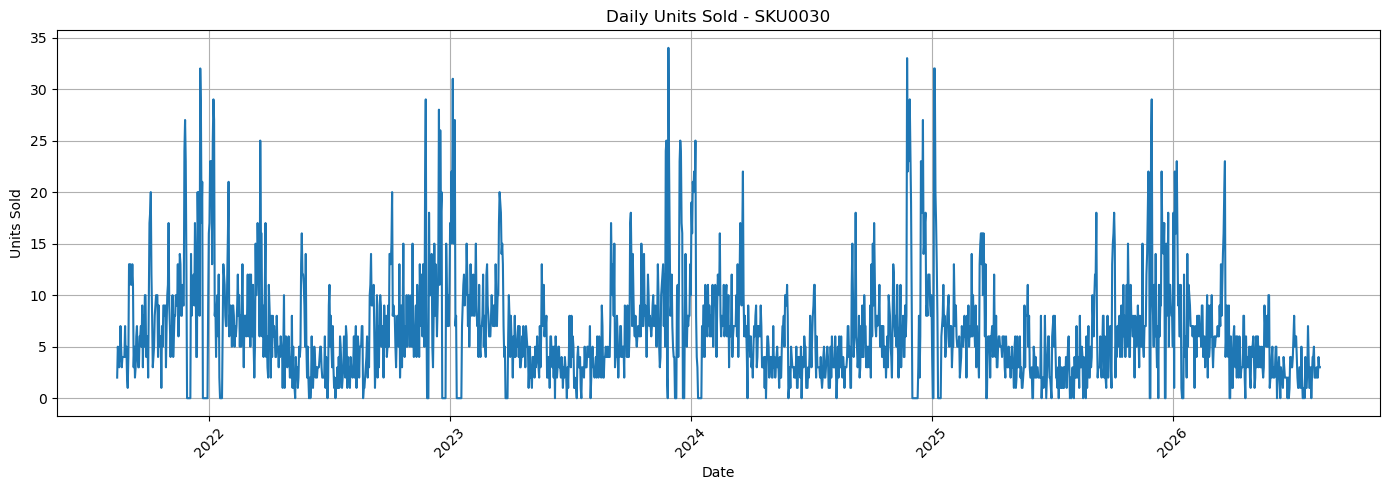

In [85]:
plt.figure(figsize=(14, 5))

plt.plot(
    sku_data["date"],
    sku_data["units_sold"]
)

plt.title(f"Daily Units Sold - {sku}")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# 3.check monthly demand

In [86]:
monthly_sales = (
    sku_data
    .set_index("date")["units_sold"]
    .resample("ME")
    .sum()
)

print(monthly_sales)

date
2021-08-31     72
2021-09-30    207
2021-10-31    270
2021-11-30    284
2021-12-31    289
             ... 
2026-04-30    113
2026-05-31    145
2026-06-30     73
2026-07-31     88
2026-08-31     36
Freq: ME, Name: units_sold, Length: 61, dtype: int64


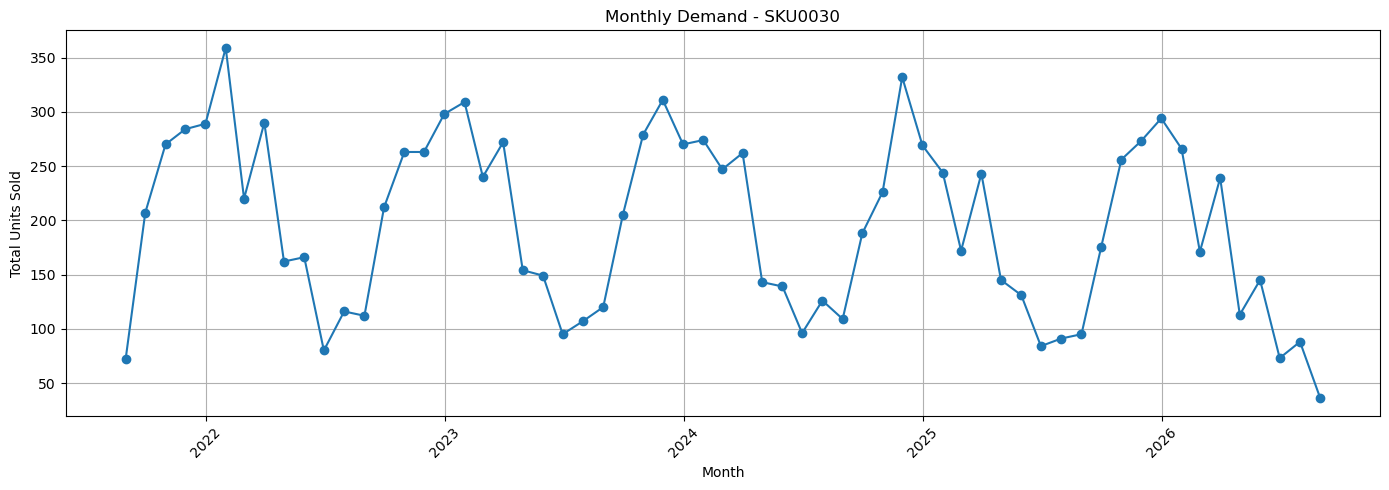

In [87]:
# plottinh
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title(f"Monthly Demand - {sku}")
plt.xlabel("Month")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# 4.check Inventory vs Demand

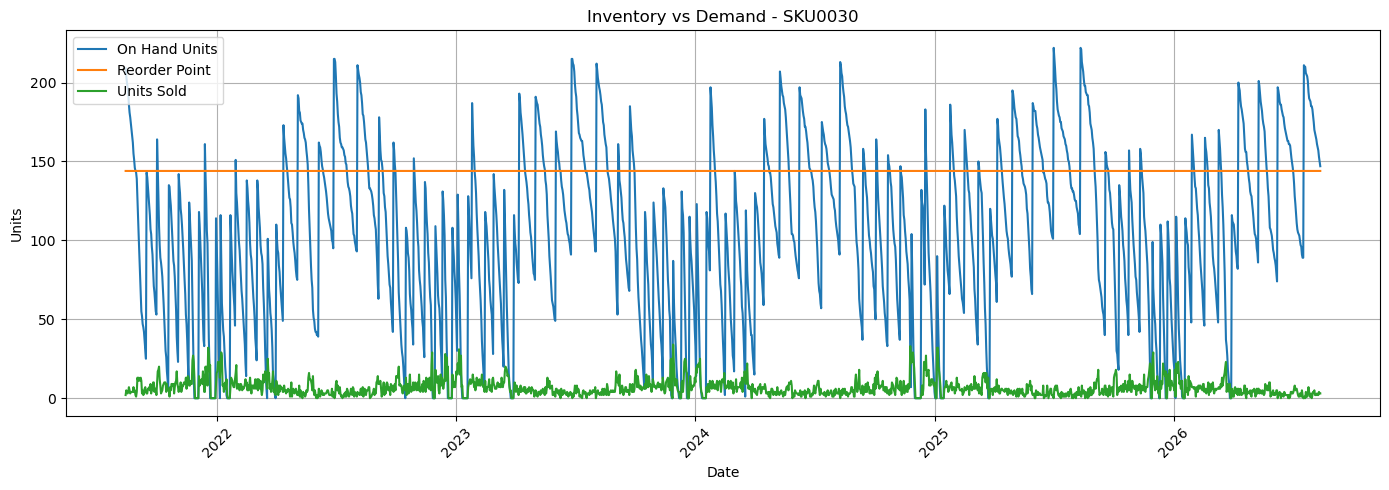

In [88]:
plt.figure(figsize=(14, 5))

plt.plot(
    sku_data["date"],
    sku_data["on_hand_units"],
    label="On Hand Units"
)

plt.plot(
    sku_data["date"],
    sku_data["reorder_point"],
    label="Reorder Point"
)

plt.plot(
    sku_data["date"],
    sku_data["units_sold"],
    label="Units Sold"
)

plt.title(f"Inventory vs Demand - {sku}")
plt.xlabel("Date")
plt.ylabel("Units")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()